### **Experiments for N-dim convex optimization problem**

We have trained more adaptive learning rate (LR) models for Gradient Descent models to be used in higher dimensions: **[5, 10, 100, 800]**

In [1]:
import gymnasium as gym
import src.gymnasium_envs.convex_optimization_env
import src.utils.exps as exps
import numpy as np
import matplotlib.pyplot as plt

seed = 42
max_iterations = 10000
env_id = "convex_optimization_env/ConvexOptimization-v1"
available_dims = [2, 5, 10, 100]
base_env_kwargs = {}

### 1. Convergence on [2, 5, 10, 100] vs. ADAM and GD 

Let's build convergence graphs for models trained on a specific dimension

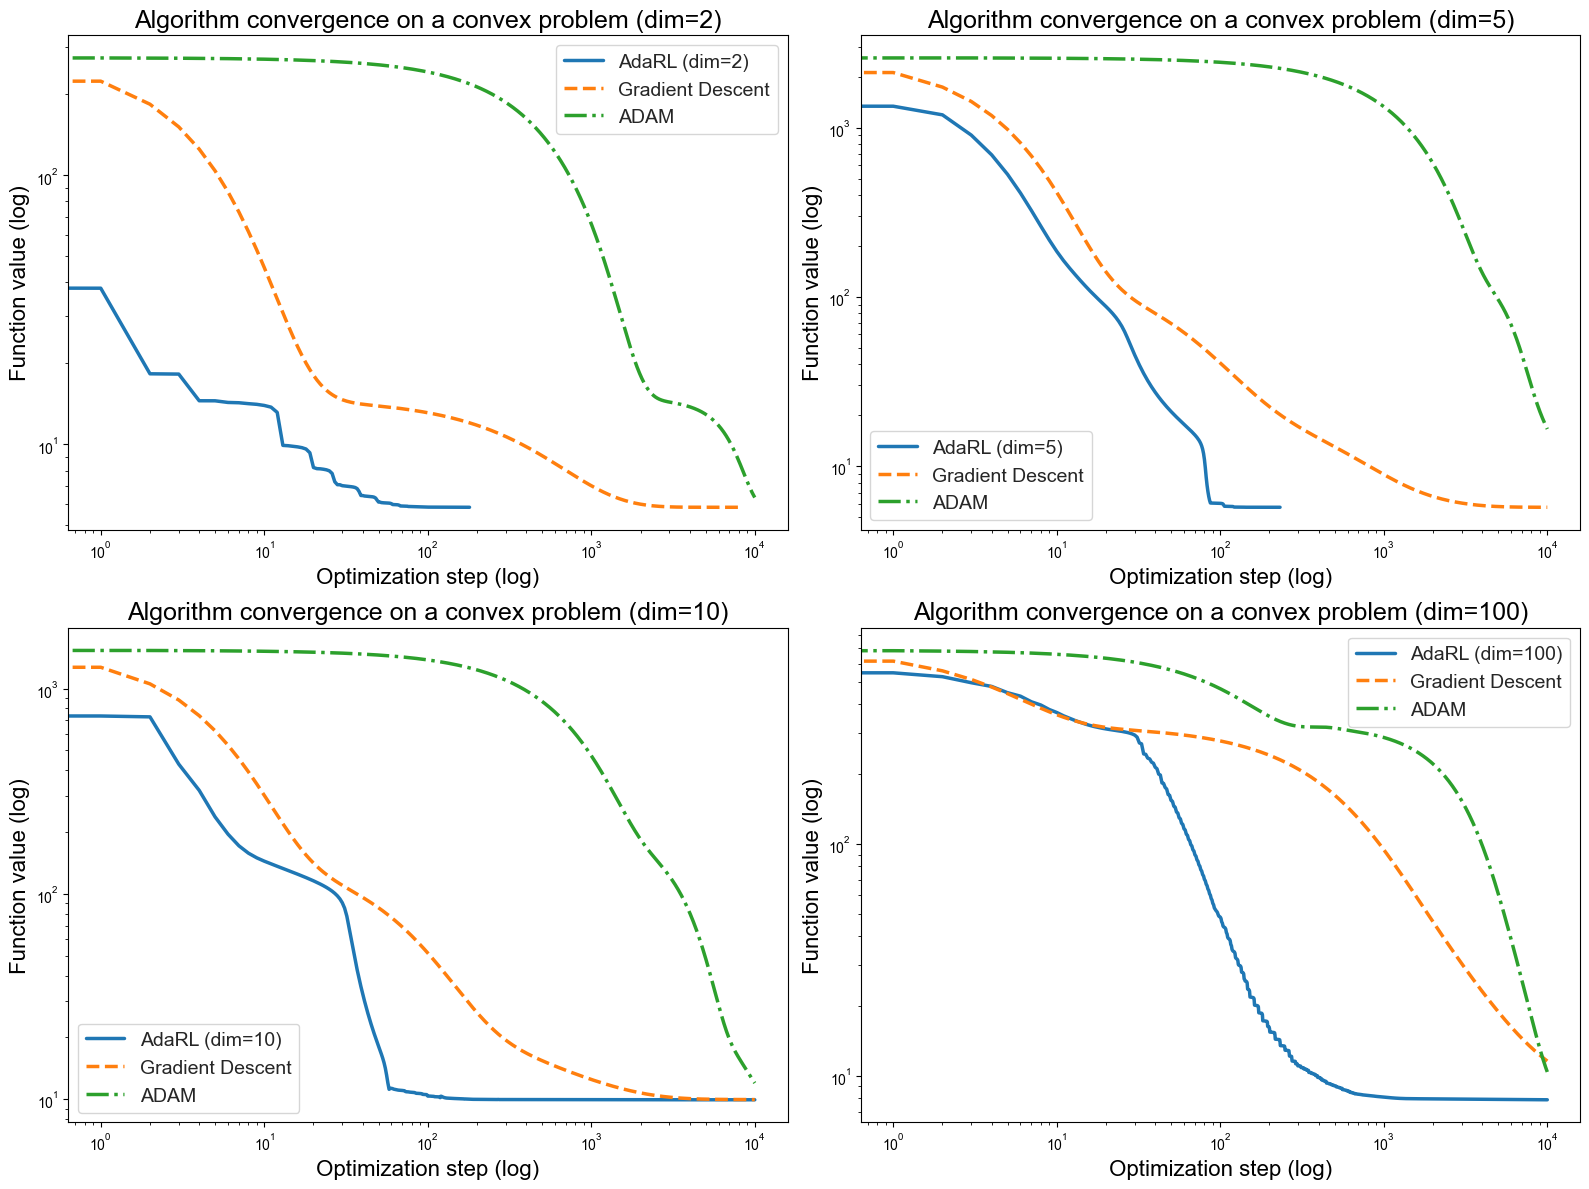

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, dim in zip(axes, available_dims):
    stats = f"../models/{dim}d_convex_vec_normalize.pkl"
    model = f"../models/{dim}d_convex"

    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    result_rl, x0, function = exps.optimize_exp_rl(
        method=f"AdaRL (dim={dim})", env_config=env_config, model_dir=model_dir
    )
    result_gdesc = exps.optimize_exp_standart(method="GD", x0=x0, function=function, env_config=env_config)
    result_adam = exps.optimize_exp_standart(method="ADAM", x0=x0, function=function, env_config=env_config)

    result = result_rl | result_gdesc | result_adam

    exps.plot_converging_comparasion(
        result, dim, title=f"Algorithm convergence on a convex problem (dim={dim})", ax=ax
    )

fig.tight_layout()
plt.show()

In [3]:
sample_count = 25

for dim in available_dims:
    print(f"Distribution of iterations number on {dim}-dim convex problem")

    stats_path = f"../models/{dim}d_convex_vec_normalize.pkl"
    model_path = f"../models/{dim}d_convex"

    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    model_dir = exps.get_model_dir(stats_path, model_path)

    result_stats = exps.plot_iterations_distribution_vs_standart(
        sample_count=sample_count, env_config=env_config, model_dir=model_dir
    )
    result_stats['mean_norm'] = np.round(result_stats['mean'] / max_iterations, 3)
    display(result_stats)

Distribution of iterations number on 2-dim convex problem


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=2),117.52,9945.37,99.73,23.0,406.0,383.0,0.012
Gradient Descent,4435.60,14106660.00,3755.88,311.0,10001.0,9690.0,0.444
ADAM,9387.40,2070468.88,1438.91,3489.0,10001.0,6512.0,0.939


Distribution of iterations number on 5-dim convex problem


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=5),785.00,3557359.12,1886.10,164.0,9999.0,9835.0,0.078
Gradient Descent,9889.28,189561.40,435.39,7846.0,10001.0,2155.0,0.989
ADAM,9933.36,109804.07,331.37,8310.0,10001.0,1691.0,0.993


Distribution of iterations number on 10-dim convex problem


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=10),8250.44,11167579.05,3341.79,573.0,9999.0,9426.0,0.825
Gradient Descent,10001.00,0.00,0.00,10001.0,10001.0,0.0,1.000
ADAM,10001.00,0.00,0.00,10001.0,10001.0,0.0,1.000


Distribution of iterations number on 100-dim convex problem


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=100),9999.0,0.0,0.0,9999.0,9999.0,0.0,1.0
Gradient Descent,10001.0,0.0,0.0,10001.0,10001.0,0.0,1.0
ADAM,10001.0,0.0,0.0,10001.0,10001.0,0.0,1.0


### 2. Convergence for different function scale parameter

For fixed dim = 5, let's compare the convergence of standard methods and adaptive LR on different scale parameters.

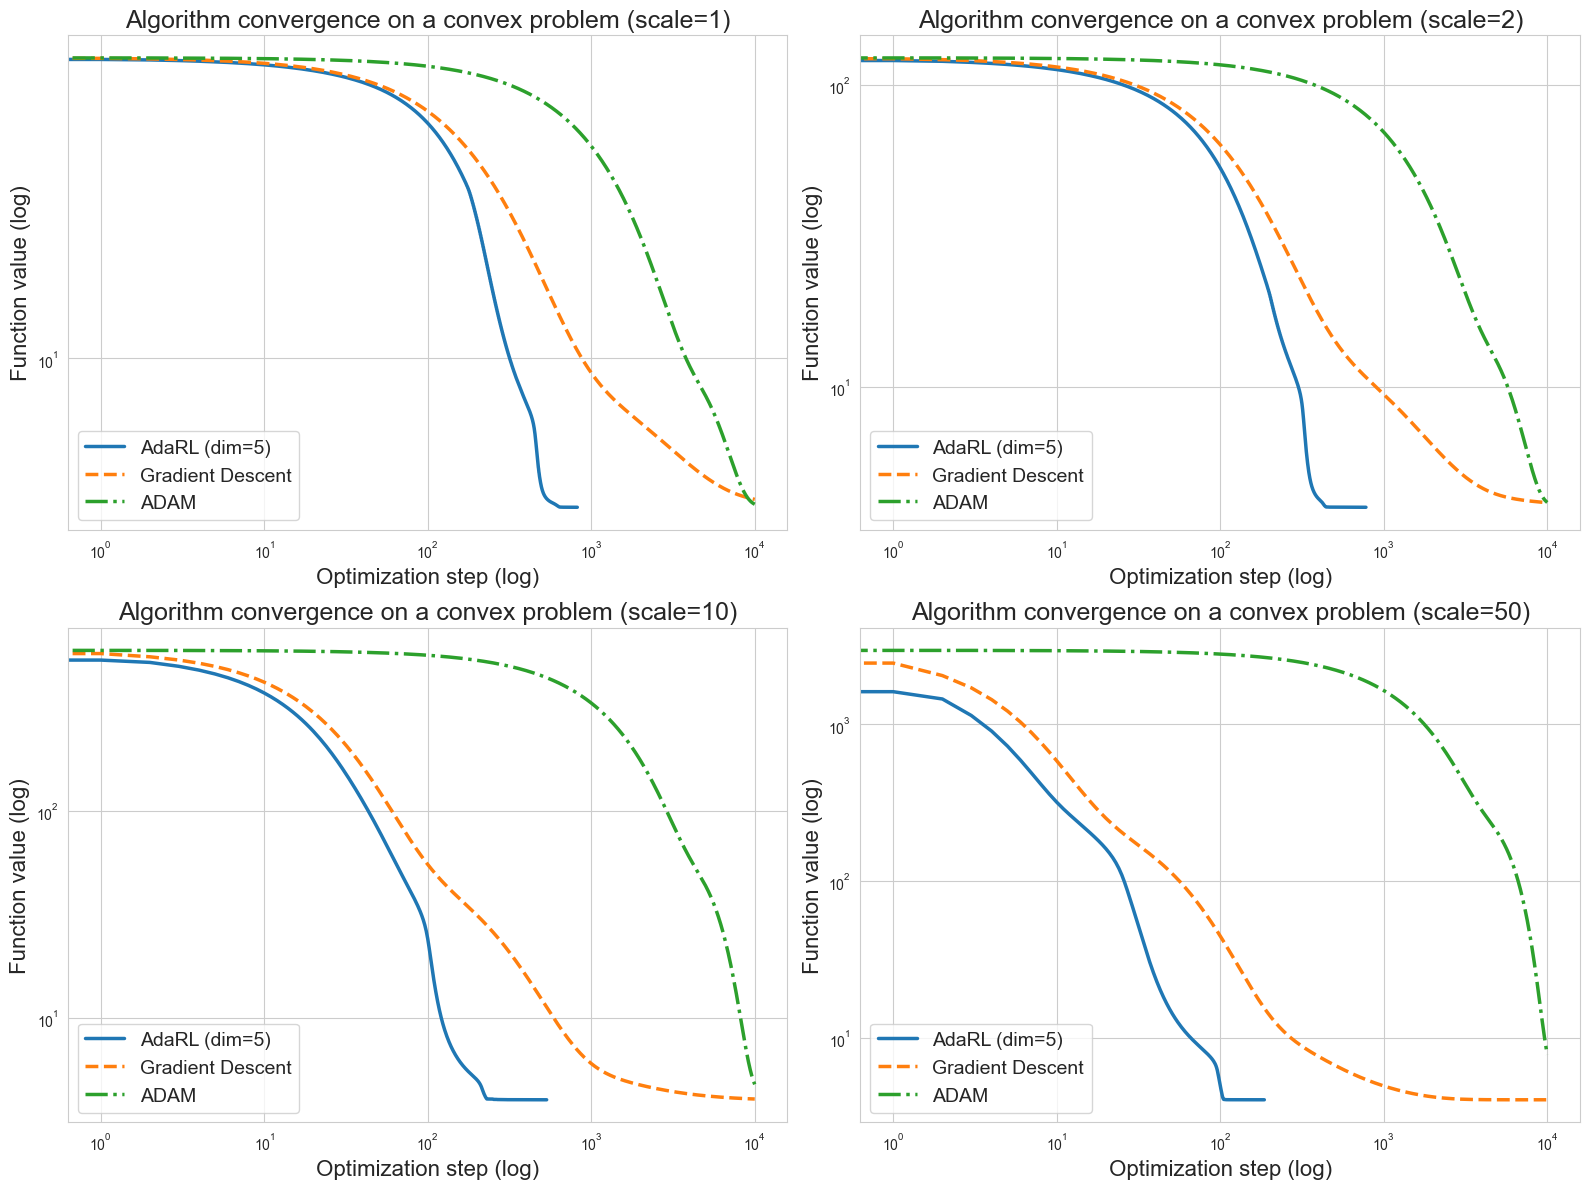

In [4]:
scales = [1, 2, 10, 50]
fixed_dim = 5

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, scale in zip(axes, scales):
    stats_path = f"../models/{fixed_dim}d_convex_vec_normalize.pkl"
    model_path = f"../models/{fixed_dim}d_convex"

    env_kwargs = {**base_env_kwargs, "scale": scale}
    env_config = exps.get_env_config(seed, fixed_dim, max_iterations, env_id, env_kwargs=env_kwargs)
    model_dir = exps.get_model_dir(stats_path, model_path)

    result_rl, x0, function = exps.optimize_exp_rl(
        method=f"AdaRL (dim={fixed_dim})", env_config=env_config, model_dir=model_dir
    )
    result_gdesc = exps.optimize_exp_standart(method="GD", x0=x0, function=function, env_config=env_config)
    result_adam = exps.optimize_exp_standart(method="ADAM", x0=x0, function=function, env_config=env_config)

    result = result_rl | result_gdesc | result_adam

    exps.plot_converging_comparasion(
        result, fixed_dim, title=f"Algorithm convergence on a convex problem (scale={scale})", ax=ax
    )

fig.tight_layout()
plt.show()

### 3. Early stop by metric vs the usual model

Let's compare the usual model against an early stop in terms of the average number of steps.

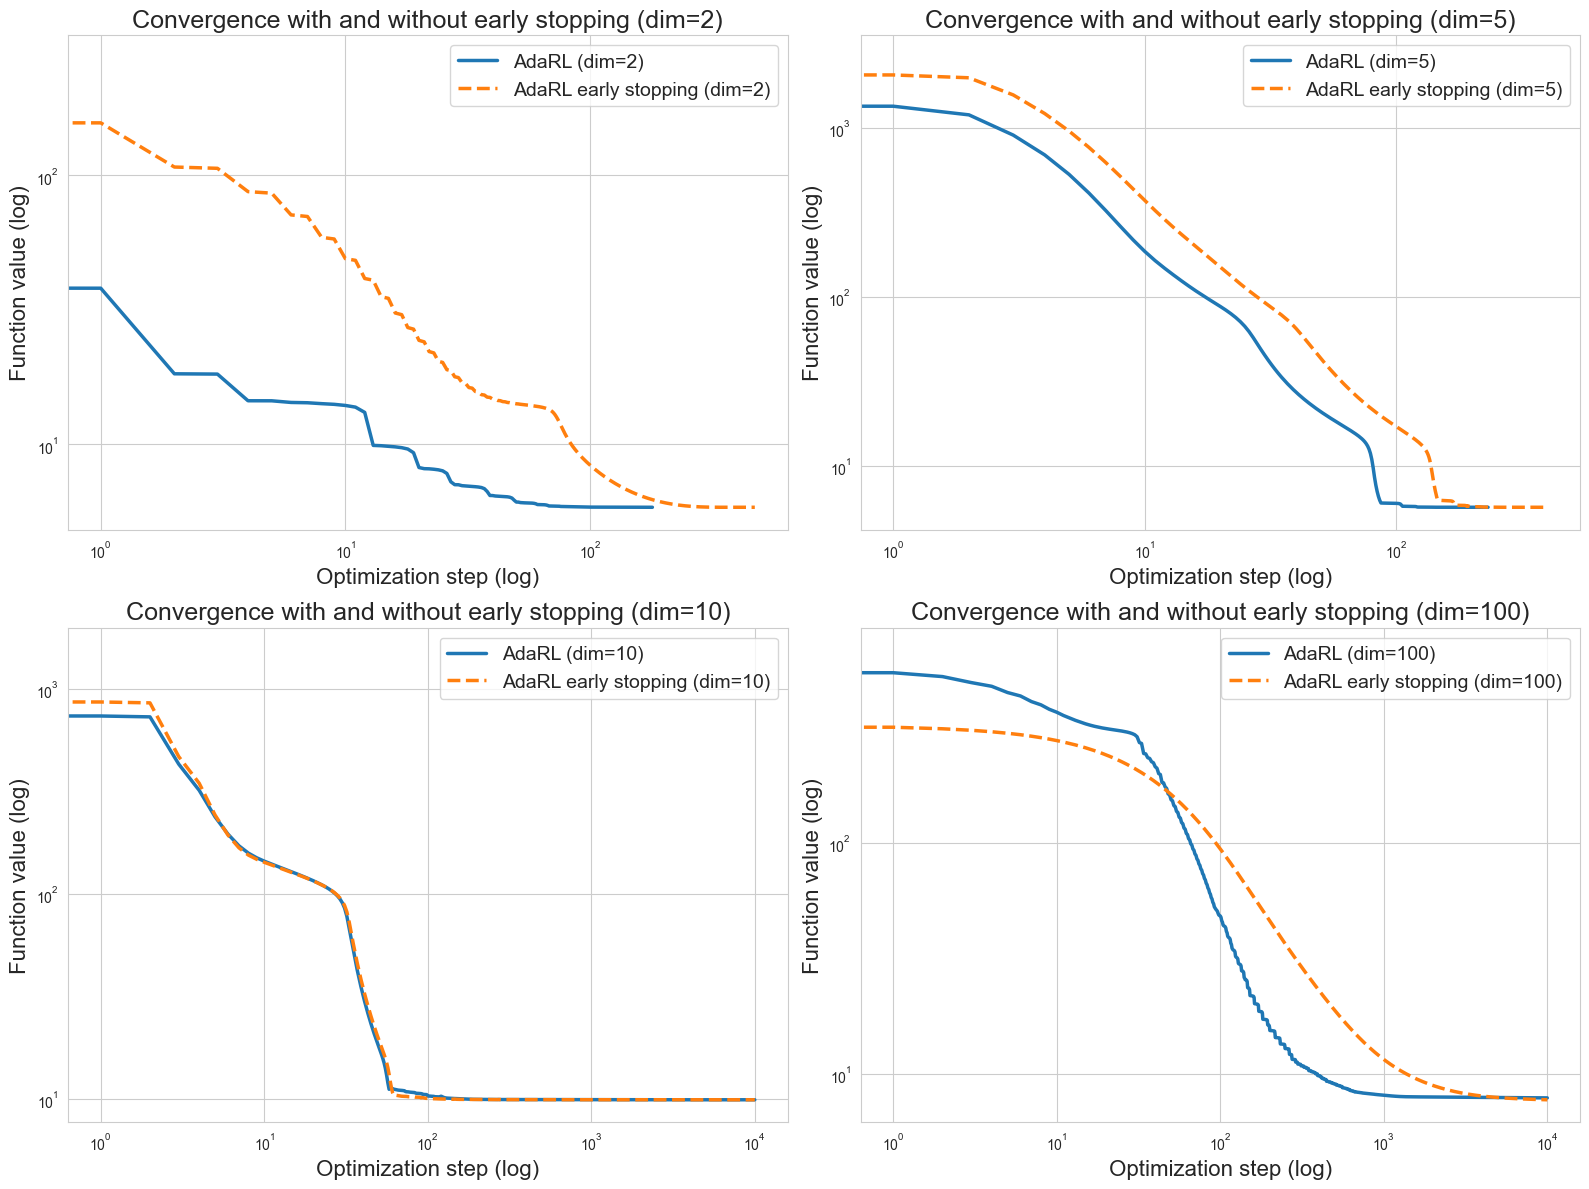

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, dim in zip(axes, available_dims):
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)

    stats_default = f"../models/{dim}d_convex_vec_normalize.pkl"
    model_default = f"../models/{dim}d_convex"
    model_dir_default = exps.get_model_dir(stats_default, model_default)

    stats_early_stopping = f"../models/{dim}d_convex_best/best_vec_normalize.pkl"
    model_early_stopping = f"../models/{dim}d_convex_best/best_model"
    model_dir_early_stopping = exps.get_model_dir(stats_early_stopping, model_early_stopping)

    result_default, x0, function = exps.optimize_exp_rl(
        method=f"AdaRL (dim={dim})", env_config=env_config, model_dir=model_dir_default
    )
    result_early_stopping, x0, function = exps.optimize_exp_rl(
        method=f"AdaRL early stopping (dim={dim})", env_config=env_config, model_dir=model_dir_early_stopping
    )

    result = result_default | result_early_stopping

    exps.plot_converging_comparasion(
        result, dim, title=f"Convergence with and without early stopping (dim={dim})", ax=ax
    )

fig.tight_layout()
plt.show()

In [6]:
sample_count = 25

for dim in available_dims:
    print(f"Distribution of iterations stop by metric vs the usual model (dim = {dim})")

    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)

    stats_default_path = f"../models/{dim}d_convex_vec_normalize.pkl"
    model_default_path = f"../models/{dim}d_convex"
    model_dir_default = exps.get_model_dir(stats_default_path, model_default_path)

    stats_early_stopping_path = f"../models/{dim}d_convex_best/best_vec_normalize.pkl"
    model_early_stopping_path = f"../models/{dim}d_convex_best/best_model"
    model_dir_early_stopping = exps.get_model_dir(stats_early_stopping_path, model_early_stopping_path)

    models = {
        f"AdaRL (dim={dim})": model_dir_default,
        f"AdaRL early stopping (dim={dim})": model_dir_early_stopping,
    }

    result_stats = exps.plot_iterations_distribution_batched(
        sample_count=sample_count, env_config=env_config, models=models
    )
    result_stats['mean_norm'] = np.round(result_stats['mean'] / max_iterations, 3)
    display(result_stats)

Distribution of iterations stop by metric vs the usual model (dim = 2)


,mean,variance,std,min,max,range,mean_norm
AdaRL (dim=2),93.60,5543.44,74.45,15.0,305.0,290.0,0.009
AdaRL early stopping (dim=2),1182.52,5039390.81,2244.86,102.0,10000.0,9898.0,0.118


Distribution of iterations stop by metric vs the usual model (dim = 5)


,mean,variance,std,min,max,range,mean_norm
AdaRL (dim=5),359.32,65861.42,256.63,103.0,1363.0,1260.0,0.036
AdaRL early stopping (dim=5),2647.88,12915106.43,3593.76,148.0,10000.0,9852.0,0.265


Distribution of iterations stop by metric vs the usual model (dim = 10)


,mean,variance,std,min,max,range,mean_norm
AdaRL (dim=10),8862.84,8031716.29,2834.03,925.0,10000.0,9075.0,0.886
AdaRL early stopping (dim=10),8905.48,6572517.93,2563.69,1261.0,10000.0,8739.0,0.891


Distribution of iterations stop by metric vs the usual model (dim = 100)


c:\Users\Lolik\Documents\GitHub\Reinforcement-learning-for-Gradient-descent\venv\Lib\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


,mean,variance,std,min,max,range,mean_norm
AdaRL (dim=100),10000.0,0.0,0.0,10000.0,10000.0,0.0,1.0
AdaRL early stopping (dim=100),10000.0,0.0,0.0,10000.0,10000.0,0.0,1.0


### 4. Random dimension model vs. fixed dimension model

Let's compare a model trained on an environment with a random dimension against a model trained on an environment with a fixed dimension

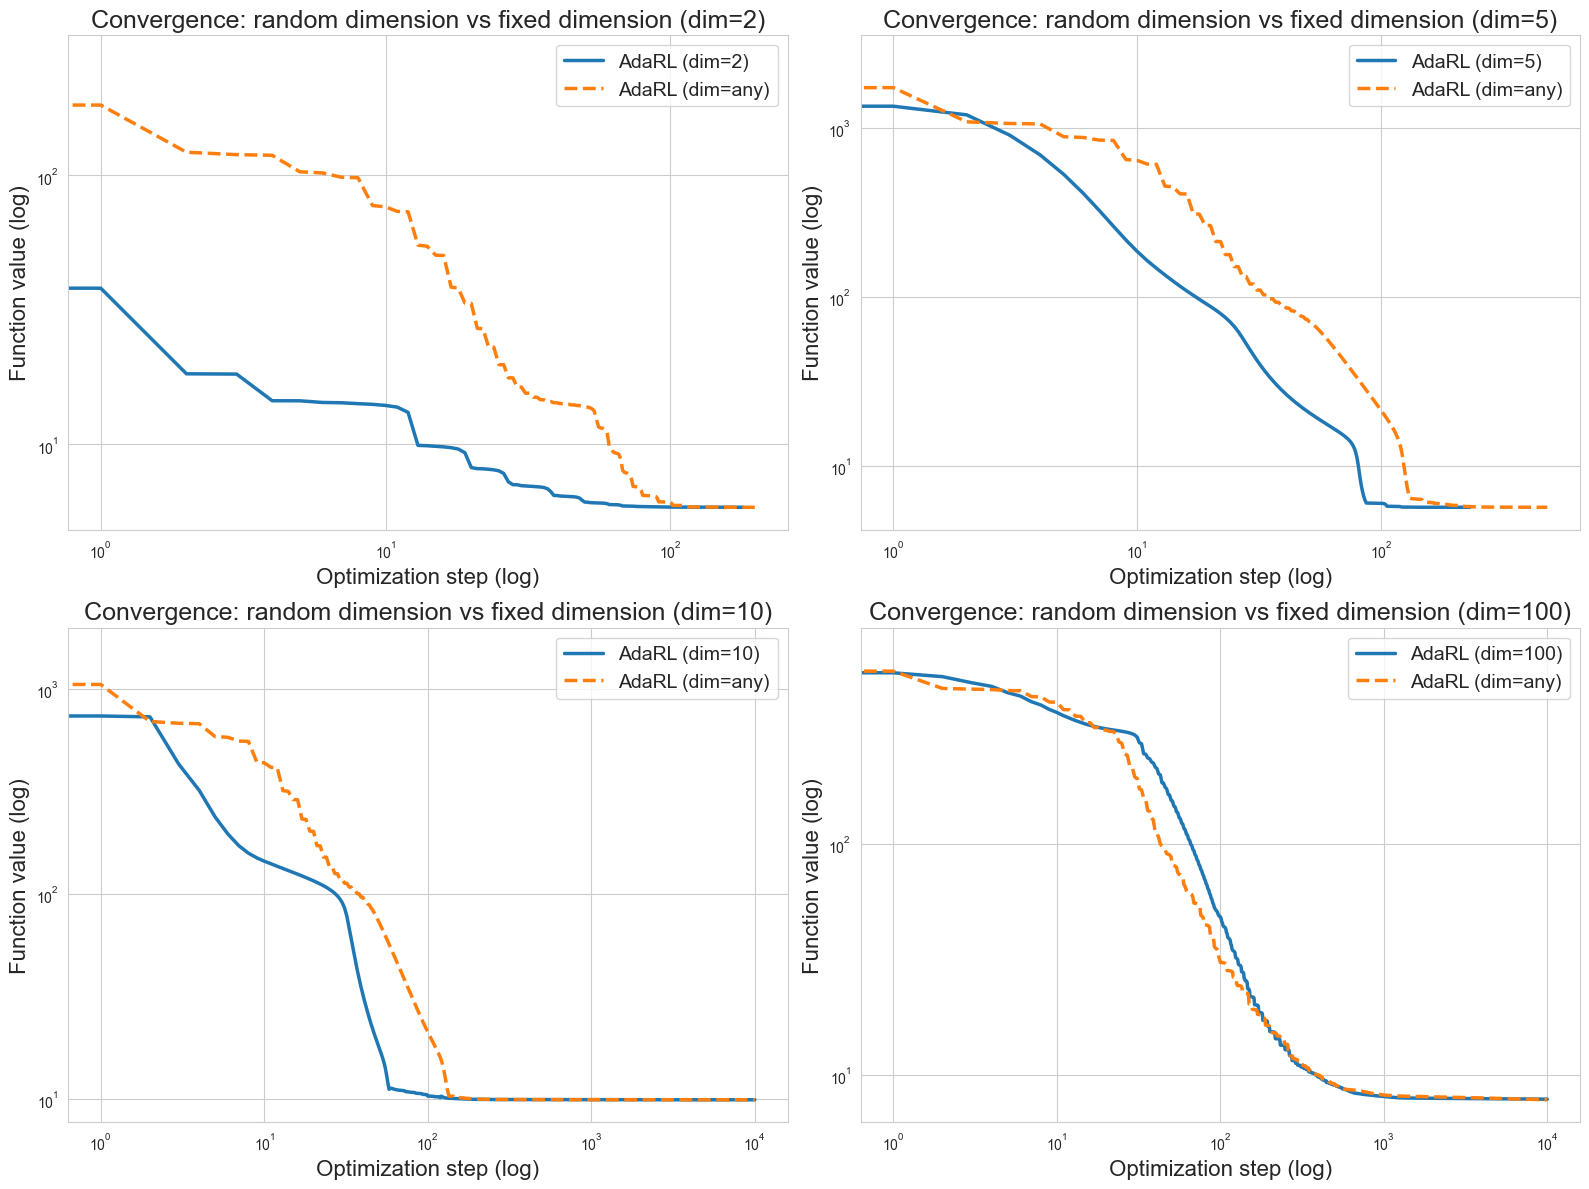

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, dim in zip(axes, available_dims):
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)

    stats_default_path = f"../models/{dim}d_convex_vec_normalize.pkl"
    model_default_path = f"../models/{dim}d_convex"
    model_dir_default = exps.get_model_dir(stats_default_path, model_default_path)

    stats_any_dim_path = "../models/anyd_convex_vec_normalize.pkl"
    model_any_dim_path = "../models/anyd_convex"
    model_dir_any_dim = exps.get_model_dir(stats_any_dim_path, model_any_dim_path)

    result_default, x0, function = exps.optimize_exp_rl(
        method=f"AdaRL (dim={dim})", env_config=env_config, model_dir=model_dir_default
    )
    result_any_d, x0, function = exps.optimize_exp_rl(
        method="AdaRL (dim=any)", env_config=env_config, model_dir=model_dir_any_dim
    )

    result = result_default | result_any_d

    exps.plot_converging_comparasion(
        result, dim, title=f"Convergence: random dimension vs fixed dimension (dim={dim})", ax=ax
    )

fig.tight_layout()
plt.show()


In [8]:
sample_count = 25

for dim in available_dims:
    print(f"Distribution of iterations number random dim vs fixed dim = {dim}")

    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)

    stats_default_path = f"../models/{dim}d_convex_vec_normalize.pkl"
    model_default_path = f"../models/{dim}d_convex"
    model_dir_default = exps.get_model_dir(stats_default_path, model_default_path)

    stats_any_dim_path = "../models/anyd_convex_vec_normalize.pkl"
    model_any_dim_path = "../models/anyd_convex"
    model_dir_any_dim = exps.get_model_dir(stats_any_dim_path, model_any_dim_path)

    models = {
        f"Adaptive LR (dim={dim})": model_dir_default,
        "Adaptive LR (dim=random)": model_dir_any_dim,
    }

    result_stats = exps.plot_iterations_distribution_batched(
        sample_count=sample_count, env_config=env_config, models=models
    )
    result_stats['mean_norm'] = np.round(result_stats['mean'] / max_iterations, 3)
    display(result_stats)

Distribution of iterations number random dim vs fixed dim = 2


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=2),93.60,5543.44,74.45,15.0,305.0,290.0,0.009
Adaptive LR (dim=random),633.36,3732560.71,1931.98,72.0,10000.0,9928.0,0.063


Distribution of iterations number random dim vs fixed dim = 5


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=5),359.32,65861.42,256.63,103.0,1363.0,1260.0,0.036
Adaptive LR (dim=random),2480.32,10096210.30,3177.45,179.0,10000.0,9821.0,0.248


Distribution of iterations number random dim vs fixed dim = 10


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=10),8862.84,8031716.29,2834.03,925.0,10000.0,9075.0,0.886
Adaptive LR (dim=random),8619.84,7881820.21,2807.46,1405.0,10000.0,8595.0,0.862


Distribution of iterations number random dim vs fixed dim = 100


,mean,variance,std,min,max,range,mean_norm
Adaptive LR (dim=100),10000.0,0.0,0.0,10000.0,10000.0,0.0,1.0
Adaptive LR (dim=random),10000.0,0.0,0.0,10000.0,10000.0,0.0,1.0


### 5. Adding a time penalty on the convergence of a random dimension model

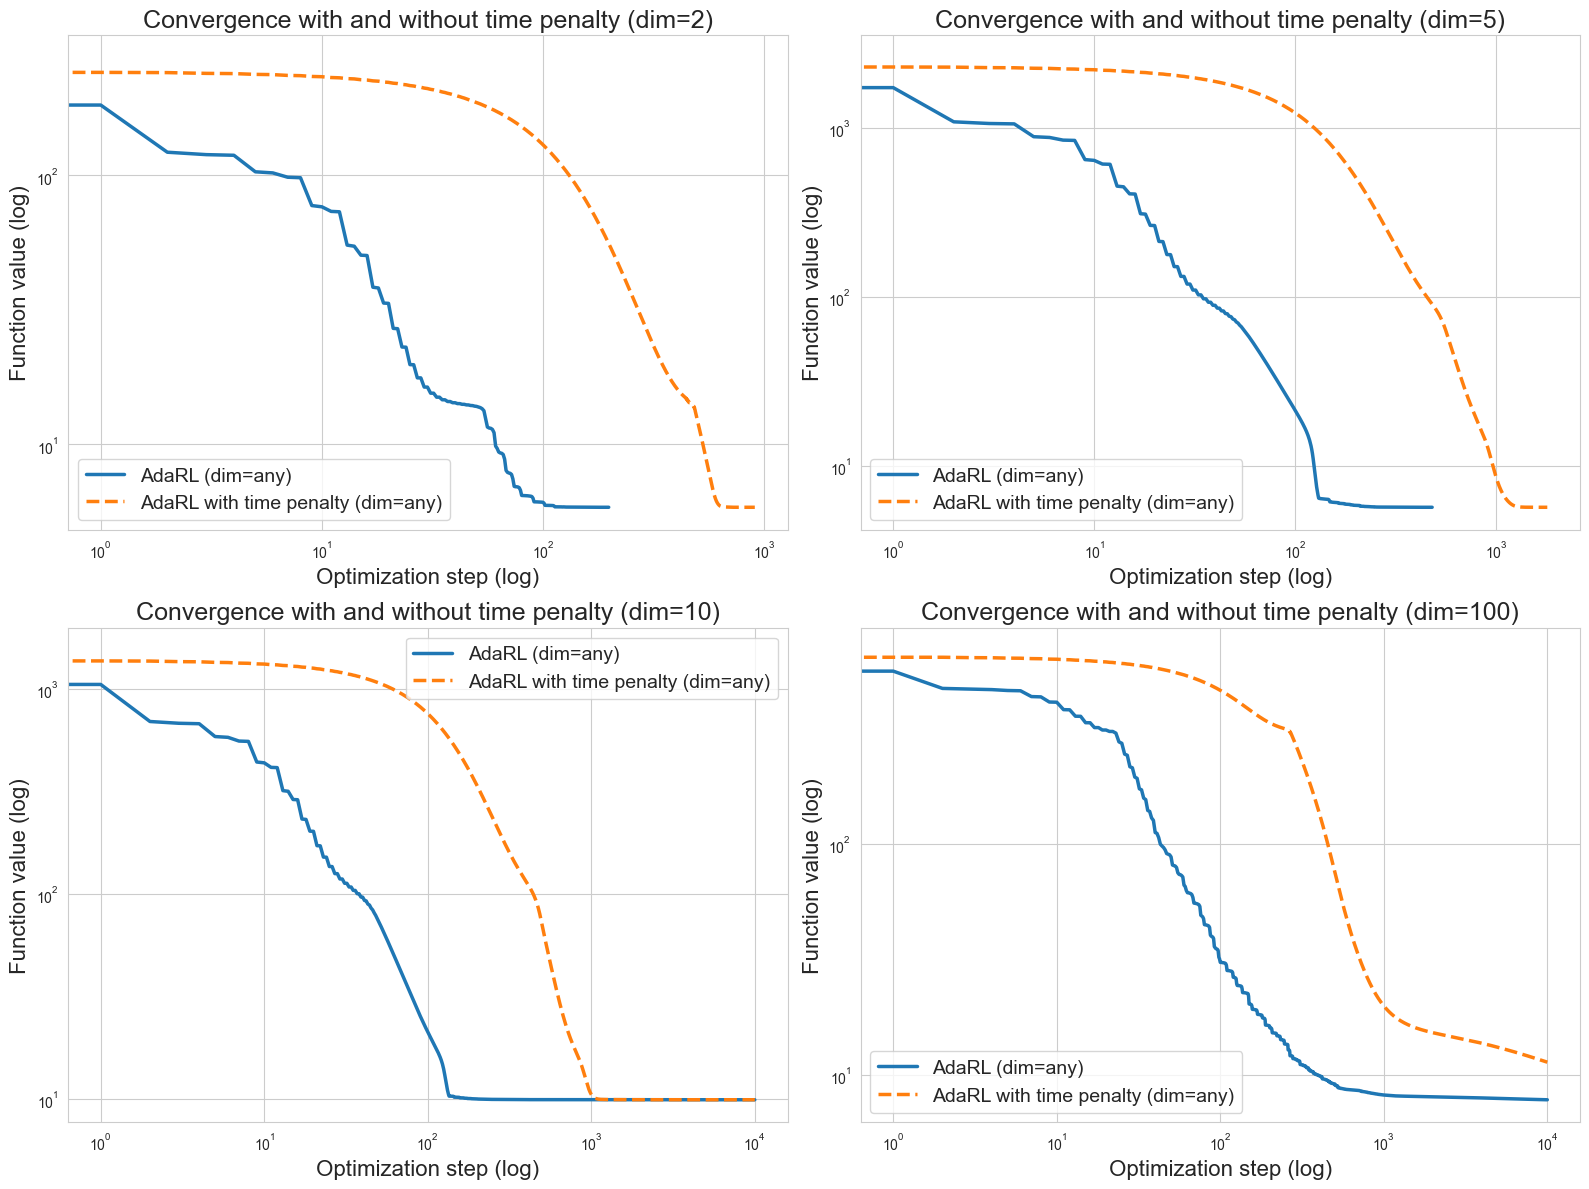

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, dim in zip(axes, available_dims):
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)

    stats_time_penalty_path = f"../models/time_penalty_anyd_convex_vec_normalize.pkl"
    model_time_penalty_path = f"../models/time_penalty_anyd_convex"
    model_dir_time_penalty = exps.get_model_dir(stats_time_penalty_path, model_time_penalty_path)

    stats_any_dim_path = "../models/anyd_convex_vec_normalize.pkl"
    model_any_dim_path = "../models/anyd_convex"
    model_dir_any_dim = exps.get_model_dir(stats_any_dim_path, model_any_dim_path)

    result_time_penalty, x0, function = exps.optimize_exp_rl(
        method="AdaRL with time penalty (dim=any)", env_config=env_config, model_dir=model_dir_time_penalty
    )
    result_any_d, x0, function = exps.optimize_exp_rl(
        method="AdaRL (dim=any)", env_config=env_config, model_dir=model_dir_any_dim
    )

    result = result_any_d | result_time_penalty

    exps.plot_converging_comparasion(
        result, dim, title=f"Convergence with and without time penalty (dim={dim})", ax=ax
    )

fig.tight_layout()
plt.show()

In [10]:
sample_count = 25

for dim in available_dims:
    print(f"Distribution of iterations with time penalty and usual model {dim}")

    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)

    stats_time_penalty_path = f"../models/time_penalty_anyd_convex_vec_normalize.pkl"
    model_time_penalty_path = f"../models/time_penalty_anyd_convex"
    model_dir_time_penalty = exps.get_model_dir(stats_time_penalty_path, model_time_penalty_path)

    stats_any_dim_path = "../models/anyd_convex_vec_normalize.pkl"
    model_any_dim_path = "../models/anyd_convex"
    model_dir_any_dim = exps.get_model_dir(stats_any_dim_path, model_any_dim_path)

    models = {
        "AdaRL with time penalty (dim=any)": model_dir_time_penalty,
        "AdaRL (dim=any)": model_dir_any_dim,
    }

    result_stats = exps.plot_iterations_distribution_batched(
        sample_count=sample_count, env_config=env_config, models=models
    )
    result_stats['mean_norm'] = np.round(result_stats['mean'] / max_iterations, 3)
    display(result_stats)

Distribution of iterations with time penalty and usual model 2


,mean,variance,std,min,max,range,mean_norm
AdaRL with time penalty (dim=any),1731.16,4194947.17,2048.16,610.0,10000.0,9390.0,0.173
AdaRL (dim=any),633.36,3732560.71,1931.98,72.0,10000.0,9928.0,0.063


Distribution of iterations with time penalty and usual model 5


,mean,variance,std,min,max,range,mean_norm
AdaRL with time penalty (dim=any),5372.80,14883514.56,3857.92,1383.0,10000.0,8617.0,0.537
AdaRL (dim=any),2480.32,10096210.30,3177.45,179.0,10000.0,9821.0,0.248


Distribution of iterations with time penalty and usual model 10


,mean,variance,std,min,max,range,mean_norm
AdaRL with time penalty (dim=any),10000.00,0.00,0.00,10000.0,10000.0,0.0,1.000
AdaRL (dim=any),8619.84,7881820.21,2807.46,1405.0,10000.0,8595.0,0.862


Distribution of iterations with time penalty and usual model 100


,mean,variance,std,min,max,range,mean_norm
AdaRL with time penalty (dim=any),10000.0,0.0,0.0,10000.0,10000.0,0.0,1.0
AdaRL (dim=any),10000.0,0.0,0.0,10000.0,10000.0,0.0,1.0
